<a href="https://colab.research.google.com/github/Saimon0007/Financial-Inclusion-across-South-and-Southeast-Asia-after-COVID-19/blob/main/Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

# -----------------------------------------------------------------------------
# 1. LOAD DATA
# -----------------------------------------------------------------------------
FILE_PATH = "/content/micro_world_139countries.csv"  # <-- change if needed

if FILE_PATH.endswith(".dta"):
    df_raw = pd.read_stata(FILE_PATH, convert_categoricals=False)
elif FILE_PATH.endswith(".csv"):
    df_raw = pd.read_csv(FILE_PATH, encoding='latin1')
else:
    raise ValueError("Set FILE_PATH to a .dta or .csv file.")

print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")
print(df_raw["economy"].nunique(), "economies in the file.")

# %%
# -----------------------------------------------------------------------------
# 2. SAFETY CHECK — confirm your target countries' exact 'economy' strings
#    before filtering. World Bank naming is usually the plain country name,
#    but a few economies use longer official forms (e.g. "Egypt, Arab Rep.",
#    "Lao PDR") — don't assume, check.
# -----------------------------------------------------------------------------
target_guess = ["India", "Bangladesh", "Pakistan", "Indonesia",
                 "Philippines", "Nepal", "Cambodia"]

all_economies = sorted(df_raw["economy"].dropna().unique())
print("Checking target country names against the file's actual 'economy' values:\n")
for c in target_guess:
    match = [e for e in all_economies if c.lower() in e.lower()]
    print(f"  {c:15s} -> found: {match if match else 'NO MATCH — inspect all_economies manually'}")

# If any show "NO MATCH", search all_economies yourself, e.g.:
# [e for e in all_economies if "nep" in e.lower()]

# %%


Loaded 143,887 rows and 128 columns.
139 economies in the file.
Checking target country names against the file's actual 'economy' values:

  India           -> found: ['India']
  Bangladesh      -> found: ['Bangladesh']
  Pakistan        -> found: ['Pakistan']
  Indonesia       -> found: ['Indonesia']
  Philippines     -> found: ['Philippines']
  Nepal           -> found: ['Nepal']
  Cambodia        -> found: ['Cambodia']


In [3]:
#SUBSET TO TARGET COUNTRIES
#    Update TARGET_COUNTRIES below using the exact strings confirmed in step 2.
# -----------------------------------------------------------------------------
TARGET_COUNTRIES = ["India", "Bangladesh", "Pakistan", "Indonesia",
                     "Philippines", "Nepal", "Cambodia"]

df = df_raw[df_raw["economy"].isin(TARGET_COUNTRIES)].copy()
print(f"Subset to {len(TARGET_COUNTRIES)} target countries: {df.shape[0]:,} rows remain.")
print(df["economy"].value_counts())

Subset to 7 target countries: 9,064 rows remain.
economy
India          3000
Indonesia      1062
Pakistan       1002
Cambodia       1000
Bangladesh     1000
Nepal          1000
Philippines    1000
Name: count, dtype: int64


In [4]:
# Save the subsetted dataframe to a CSV file
output_path = "/content/micro_world_subset.csv"
df.to_csv(output_path, index=False)
print(f"Subset successfully saved to {output_path}")

Subset successfully saved to /content/micro_world_subset.csv


In [5]:

# --- Gender: recode 1/2 -> 1/0, female = 1 ---
df["female_d"] = np.where(df["female"] == 1, 1,
                    np.where(df["female"] == 2, 0, np.nan))

# --- Age and age-squared ---
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["age2"] = df["age"] ** 2

# --- Education: keep as ordinal control, and also as dummies for flexibility ---
df["educ"] = pd.to_numeric(df["educ"], errors="coerce")
df["educ_secondary"] = (df["educ"] == 2).astype("Int64")
df["educ_tertiary"] = (df["educ"] == 3).astype("Int64")
# educ == 1 (primary or less) is the omitted/reference category

# --- Income quintile: keep as ordinal, and as dummies ---
df["inc_q"] = pd.to_numeric(df["inc_q"], errors="coerce")

# --- Employment: recode 1/2 -> 1/0, in workforce = 1 ---
df["emp_in_d"] = np.where(df["emp_in"] == 1, 1,
                    np.where(df["emp_in"] == 2, 0, np.nan))

# --- Rural/urban: recode 1/2 -> 1/0, rural = 1. Check coverage first. ---
if "urbanicity_f2f" in df.columns:
    df["rural_d"] = np.where(df["urbanicity_f2f"] == 1, 1,
                       np.where(df["urbanicity_f2f"] == 2, 0, np.nan))
    coverage = df.groupby("economy")["rural_d"].apply(lambda x: x.notna().mean())
    print("Rural/urban variable coverage by country (share non-missing):")
    print(coverage.round(3))
    print("\nPer the proposal's Section 3 risk note: for any country below ~0.5,")
    print("drop the rural/urban interaction for that country rather than the")
    print("whole analysis.")
else:
    print("WARNING: 'urbanicity_f2f' not found in this file — rural/urban")
    print("interactions (H2/step 5) will not be available for any country.")
    df["rural_d"] = np.nan

# --- Outcome variables: already 0/1 per codebook, just enforce numeric + labels ---
for var in ["account", "account_fin", "account_mob"]:
    if var not in df.columns:
        raise KeyError(f"Expected outcome variable '{var}' not found in the "
                        f"data. Check the codebook / file version.")
    df[var] = pd.to_numeric(df[var], errors="coerce")

# --- Survey weight ---
df["wgt"] = pd.to_numeric(df["wgt"], errors="coerce")

print("\nConstructed variables added: female_d, age2, educ_secondary, "
      "educ_tertiary, emp_in_d, rural_d")

Rural/urban variable coverage by country (share non-missing):
economy
Bangladesh     1.0
Cambodia       1.0
India          1.0
Indonesia      1.0
Nepal          1.0
Pakistan       1.0
Philippines    0.0
Name: rural_d, dtype: float64

Per the proposal's Section 3 risk note: for any country below ~0.5,
drop the rural/urban interaction for that country rather than the
whole analysis.

Constructed variables added: female_d, age2, educ_secondary, educ_tertiary, emp_in_d, rural_d


In [7]:
# 5. MISSINGNESS CHECK
#    Report missingness for every variable this design depends on, by country,
#    so you catch a country-specific gap (e.g. rural/urban) before modeling.
# -----------------------------------------------------------------------------
core_vars = ["female_d", "age", "educ", "inc_q", "emp_in_d", "rural_d",
             "account", "account_fin", "account_mob", "wgt"]

missing_by_country = (
    df.groupby("economy")[core_vars]
      .apply(lambda x: x.isna().mean())
      .round(3)
)
print("Share missing, by country and variable:\n")
print(missing_by_country)

# Flag anything above a 5% missingness threshold for a closer look
threshold = 0.05
flagged = missing_by_country[(missing_by_country > threshold).any(axis=1)]
if not flagged.empty:
    print(f"\nCountries/variables exceeding {threshold:.0%} missing — inspect before modeling:")
    print(flagged)
else:
    print(f"\nNo variable exceeds {threshold:.0%} missing in any target country.")

# Drop rows missing the core outcome/predictor set (keep rural_d optional,
# since its absence is expected and handled per-country rather than case-wise)
required_for_model = ["female_d", "age", "educ", "inc_q", "emp_in_d",
                       "account", "account_fin", "account_mob", "wgt"]
n_before = len(df)
df_clean = df.dropna(subset=required_for_model).copy()
print(f"\nDropped {n_before - len(df_clean):,} rows missing a required variable "
      f"({(n_before - len(df_clean)) / n_before:.1%} of the target-country sample).")
print(f"Analysis sample: {len(df_clean):,} respondents across "
      f"{df_clean['economy'].nunique()} countries.")

Share missing, by country and variable:

             female_d    age  educ  inc_q  emp_in_d  rural_d  account  \
economy                                                                 
Bangladesh        0.0  0.000   0.0    0.0       0.0      0.0      0.0   
Cambodia          0.0  0.000   0.0    0.0       0.0      0.0      0.0   
India             0.0  0.000   0.0    0.0       0.0      0.0      0.0   
Indonesia         0.0  0.000   0.0    0.0       0.0      0.0      0.0   
Nepal             0.0  0.000   0.0    0.0       0.0      0.0      0.0   
Pakistan          0.0  0.001   0.0    0.0       0.0      0.0      0.0   
Philippines       0.0  0.001   0.0    0.0       0.0      1.0      0.0   

             account_fin  account_mob  wgt  
economy                                     
Bangladesh           0.0          0.0  0.0  
Cambodia             0.0          0.0  0.0  
India                0.0          0.0  0.0  
Indonesia            0.0          0.0  0.0  
Nepal                0.0       

In [8]:
# for every country-level and descriptive step above; use 'wgt_pooled'
# only in the Day 10-11 pooled model, and report the population-weighted
# version (raw 'wgt') as a robustness check per Section 4, step 7.
# -----------------------------------------------------------------------------
df_clean["wgt_pooled"] = (
    df_clean.groupby("economy")["wgt"]
    .transform(lambda w: w / w.sum())  # each country's weights now sum to 1
)
# Now every country contributes equally to a pooled regression using
# wgt_pooled, independent of both raw N and national population size.

check = df_clean.groupby("economy")["wgt_pooled"].sum().round(6)
print("Sanity check — each country's pooled weight should sum to 1.0:")
print(check)


Sanity check — each country's pooled weight should sum to 1.0:
economy
Bangladesh     1.0
Cambodia       1.0
India          1.0
Indonesia      1.0
Nepal          1.0
Pakistan       1.0
Philippines    1.0
Name: wgt_pooled, dtype: float64


In [9]:
df_clean.to_csv("/content/findex_7country_clean.csv", index=False)
print("Saved cleaned dataset to /content/findex_7country_clean.csv")

Saved cleaned dataset to /content/findex_7country_clean.csv


In [10]:
# DAY 6 — DESCRIPTIVE STATISTICS: WEIGHTED GENDER GAP BY COUNTRY, BY CHANNEL
# =============================================================================

# %%
def weighted_mean(x, w):
    """Survey-weighted mean, ignoring rows where the value or weight is NaN."""
    mask = x.notna() & w.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])

def weighted_gap_table(data, outcome_vars, group_var="economy"):
    """
    For each country, compute the survey-weighted mean of each outcome
    separately for women and men, and the gap (men - women, in percentage
    points). This is the raw/unadjusted gap described in Section 4, step 1
    of the proposal — not yet the marginal-effects version from step 2.
    """
    rows = []
    for country, g in data.groupby(group_var):
        row = {"economy": country, "n": len(g)}
        for var in outcome_vars:
            w_female = weighted_mean(g.loc[g["female_d"] == 1, var],
                                      g.loc[g["female_d"] == 1, "wgt"])
            w_male = weighted_mean(g.loc[g["female_d"] == 0, var],
                                    g.loc[g["female_d"] == 0, "wgt"])
            row[f"{var}_female"] = w_female
            row[f"{var}_male"] = w_male
            row[f"{var}_gap_pp"] = (w_male - w_female) * 100
        rows.append(row)
    return pd.DataFrame(rows).sort_values("economy").reset_index(drop=True)

outcome_vars = ["account", "account_fin", "account_mob"]
gap_table = weighted_gap_table(df_clean, outcome_vars)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
print("Survey-weighted gender gap in account ownership, by country and channel:\n")
print(gap_table[["economy", "n"] +
                 [c for v in outcome_vars for c in
                  (f"{v}_female", f"{v}_male", f"{v}_gap_pp")]])

Survey-weighted gender gap in account ownership, by country and channel:

       economy     n  account_female  account_male  account_gap_pp  \
0   Bangladesh  1000           0.435         0.629          19.406   
1     Cambodia  1000           0.325         0.344           1.888   
2        India  3000           0.776         0.775          -0.045   
3    Indonesia  1062           0.523         0.512          -1.123   
4        Nepal  1000           0.499         0.586           8.707   
5     Pakistan  1001           0.135         0.282          14.631   
6  Philippines   999           0.474         0.553           7.854   

   account_fin_female  account_fin_male  account_fin_gap_pp  \
0               0.306             0.453              14.758   
1               0.313             0.341               2.821   
2               0.775             0.771              -0.317   
3               0.517             0.493              -2.384   
4               0.497             0.563           

In [11]:
gap_table.to_csv("/content/weighted_gender_gap_by_country.csv", index=False)
print("\nSaved to /content/weighted_gender_gap_by_country.csv")


Saved to /content/weighted_gender_gap_by_country.csv


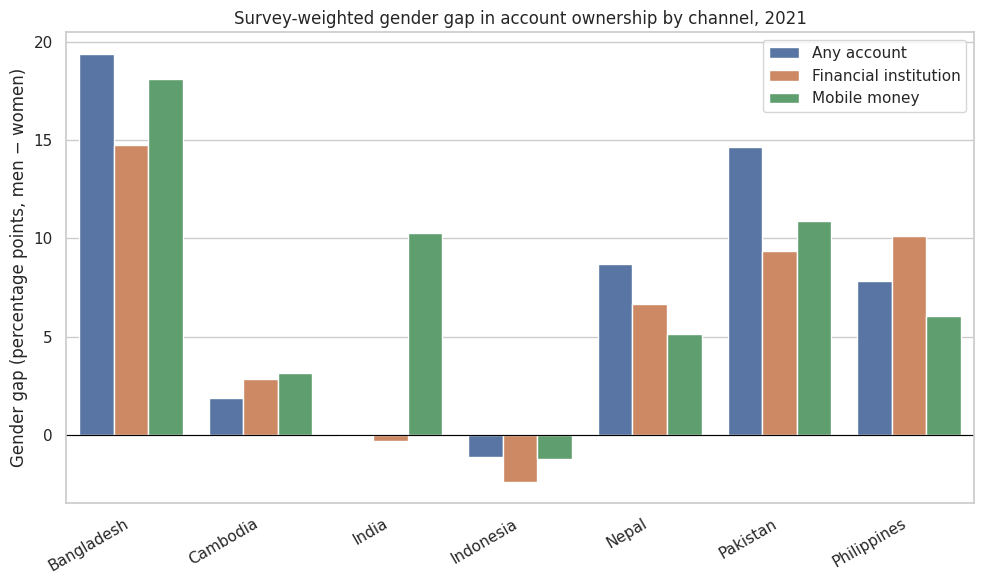

In [12]:
# EXPLORATORY CHART 1 — Grouped bar chart: gender gap (pp) by country, by channel
plot_df = gap_table.melt(
    id_vars="economy",
    value_vars=[f"{v}_gap_pp" for v in outcome_vars],
    var_name="channel", value_name="gap_pp"
)
plot_df["channel"] = plot_df["channel"].str.replace("_gap_pp", "", regex=False)
plot_df["channel"] = plot_df["channel"].map({
    "account": "Any account",
    "account_fin": "Financial institution",
    "account_mob": "Mobile money"
})

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="economy", y="gap_pp", hue="channel")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Gender gap (percentage points, men − women)")
plt.xlabel("")
plt.title("Survey-weighted gender gap in account ownership by channel, 2021")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig("/content/gender_gap_by_country_channel.png", dpi=150)
plt.show()

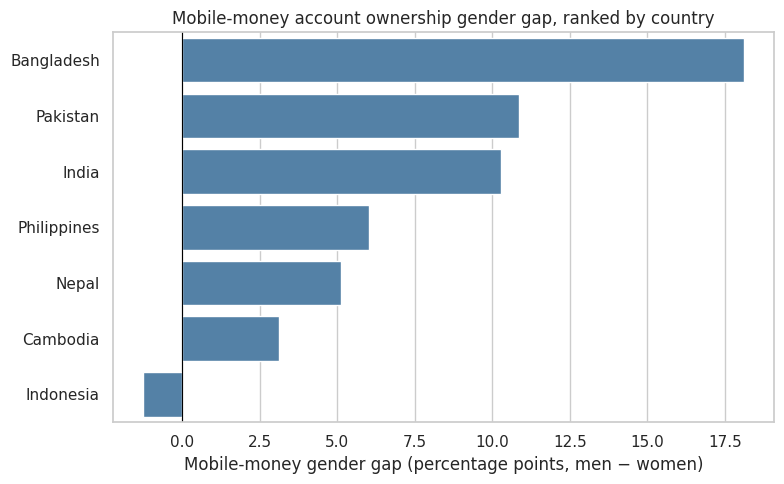

In [13]:
# EXPLORATORY CHART 2 — Country ranking on the mobile-money channel specifically
#    (the channel this paper's core comparison hinges on)
mob_sorted = gap_table.sort_values("account_mob_gap_pp", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=mob_sorted, x="account_mob_gap_pp", y="economy",
            color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Mobile-money gender gap (percentage points, men − women)")
plt.ylabel("")
plt.title("Mobile-money account ownership gender gap, ranked by country")
plt.tight_layout()
plt.savefig("/content/mobile_money_gap_ranked.png", dpi=150)
plt.show()

In [14]:
# EXPLORATORY CHART 3 — Sample size sanity check (per-country n, split by gender)
#    Cheap check before doing anything statistical: flag any country/gender
#    cell that's too thin to support reliable marginal effects later.
n_table = (
    df_clean.groupby(["economy", "female_d"])
    .size()
    .unstack()
    .rename(columns={0: "n_male", 1: "n_female"})
)
n_table["total"] = n_table.sum(axis=1)
print("Sample size by country and gender:\n")
print(n_table)

if (n_table[["n_male", "n_female"]] < 200).any(axis=None):
    print("\nWARNING: at least one country-gender cell has fewer than 200 "
          "respondents — country-level marginal effects for that cell "
          "(Section 4, step 2) may be imprecise. Check before proceeding.")


Sample size by country and gender:

female_d     n_male  n_female  total
economy                             
Bangladesh      412       588   1000
Cambodia        352       648   1000
India          1618      1382   3000
Indonesia       460       602   1062
Nepal           454       546   1000
Pakistan        499       502   1001
Philippines     426       573    999
